In [7]:
import os
import shutil

# Create Kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Copy your Kaggle API key
shutil.copy('/content/kaggle (1).json', '/root/.kaggle/kaggle.json')

# Set correct permissions
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [8]:
!pip install -q kaggle

In [9]:
!kaggle datasets download -d dheerajperumandla/drowsiness-dataset

Dataset URL: https://www.kaggle.com/datasets/dheerajperumandla/drowsiness-dataset
License(s): unknown
100% 161M/161M [00:02<00:00, 80.0MB/s]



In [10]:
import zipfile
import os

zip_path = '/content/drowsiness-dataset.zip'
extract_path = '/content/drowsiness_dataset'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [11]:
import os

for root, dirs, files in os.walk('/content/drowsiness_dataset'):
    level = root.replace('/content/drowsiness_dataset', '').count(os.sep)
    indent = '    ' * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

drowsiness_dataset/
    train/
        Open/
        Closed/
        no_yawn/
        yawn/


In [12]:
from pathlib import Path

dataset_path = Path("/content/drowsiness_dataset/train")

for class_dir in sorted(dataset_path.iterdir()):
    if class_dir.is_dir():
        images = list(class_dir.glob("*"))
        print(f"{class_dir.name:10} : {len(images)} images")

Closed     : 726 images
Open       : 726 images
no_yawn    : 725 images
yawn       : 723 images


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [14]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
Num GPUs: 1


In [15]:
CLASS_NAMES = [
    "Closed",
    "Open",
    "no_yawn",
    "yawn"
]

print(CLASS_NAMES)
assert CLASS_NAMES == ["Closed", "Open", "no_yawn", "yawn"]

['Closed', 'Open', 'no_yawn', 'yawn']


In [16]:
from pathlib import Path

EXTRACT_DIR = Path(extract_path)

train_candidates = [
    p for p in EXTRACT_DIR.rglob("train")
    if all((p / cls).exists() for cls in CLASS_NAMES)
]

if not train_candidates:
    raise FileNotFoundError(
        "Could not find a train directory containing all four classes."
    )

DATASET_DIR = train_candidates[0]

print("Dataset directory:")
print(DATASET_DIR)

Dataset directory:
/content/drowsiness_dataset/train


In [17]:
import pandas as pd
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

def get_image_files(directory):
    return sorted(
        p for p in directory.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

all_records = []

for class_index, class_name in enumerate(CLASS_NAMES):
    class_dir = DATASET_DIR / class_name

    image_files = get_image_files(class_dir)

    for path in image_files:
        all_records.append({
            "path": str(path),
            "label": class_index,
            "class_name": class_name
        })

df = pd.DataFrame(all_records)

print("\nImage counts:")
print(df["class_name"].value_counts().reindex(CLASS_NAMES))

print("\nTotal images:", len(df))


Image counts:
class_name
Closed     726
Open       726
no_yawn    725
yawn       723
Name: count, dtype: int64

Total images: 2900


In [18]:
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = False

invalid_images = []

for path in df["path"]:
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            img.convert("RGB")

    except Exception as exc:
        invalid_images.append({
            "path": path,
            "error": str(exc)
        })

print("Invalid images:", len(invalid_images))

if invalid_images:
    display(pd.DataFrame(invalid_images).head(20))

Invalid images: 0


In [19]:
import hashlib
def file_hash(path):
    sha = hashlib.sha256()

    with open(path, "rb") as f:
        while True:
            chunk = f.read(1024 * 1024)

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


hash_to_records = {}

for path in df["path"]:
    h = file_hash(path)
    hash_to_records.setdefault(h, []).append(path)

duplicate_groups = [
    paths for paths in hash_to_records.values()
    if len(paths) > 1
]

print("Exact duplicate groups:", len(duplicate_groups))

for group in duplicate_groups[:10]:
    print(group)

Exact duplicate groups: 0


In [20]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SIZE = 0.20

In [21]:
import os
import json
import random
import shutil
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split

The previous train/validation split has been replaced by a new 70/15/15 train/validation/test split. The new splitting logic is implemented in the subsequent code cells (`1a88f312`). Please ensure the DataFrame `df` is defined from previous cells before running the new split.

### 1. Improved Data Splitting

Upon inspecting the dataset structure, it was determined that there are no explicit subject/person IDs, video IDs, or subject-encoding filenames or folders. Therefore, a subject-independent split cannot be performed. The data will be split at the image level, ensuring stratification by class.

We will create a 70% training, 15% validation, and 15% test split. This ensures that the model is evaluated on a separate, unseen test set, providing a more robust measure of its generalization performance.

In [22]:
from sklearn.model_selection import train_test_split

# Split 1: Original DataFrame into 70% temporary train and 30% remaining
train_df, remaining_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

# Split 2: Remaining 30% into 15% validation and 15% test
val_df, test_df = train_test_split(
    remaining_df,
    test_size=0.50, # 0.50 of 30% is 15%
    random_state=SEED,
    stratify=remaining_df["label"]
)

# Reset indices for all DataFrames
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Test images: {len(test_df)}")

Training images: 2030
Validation images: 435
Test images: 435


In [23]:
print("\nTraining distribution:")
print(
    train_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("\nValidation distribution:")
print(
    val_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("\nTest distribution:")
print(
    test_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)


Training distribution:
class_name
Closed     508
Open       508
no_yawn    508
yawn       506
Name: count, dtype: int64

Validation distribution:
class_name
Closed     109
Open       109
no_yawn    109
yawn       108
Name: count, dtype: int64

Test distribution:
class_name
Closed     109
Open       109
no_yawn    108
yawn       109
Name: count, dtype: int64


As confirmed by the distributions above, the split is stratified at the image level. The notebook will continue with this 70/15/15 train/validation/test split for all subsequent analyses and model training.

### 2. Data Quality Check

Before proceeding with model training, it is crucial to perform a thorough data quality analysis. We will check for image dimensions, and, critically, ensure there is no leakage of duplicate images between the newly created train, validation, and test sets. We have already confirmed in earlier steps that there are no corrupted images or exact duplicates within the entire dataset.

In [24]:
# Check Image Dimensions
# This function will verify that all images conform to the expected dimensions after preprocessing.
def check_image_dimensions(dataframe, expected_size=IMAGE_SIZE):
    anomalies = []
    for idx, row in dataframe.iterrows():
        try:
            with Image.open(row['path']) as img:
                if img.size[0] != expected_size or img.size[1] != expected_size:
                    anomalies.append({
                        "path": row['path'],
                        "actual_size": img.size,
                        "class_name": row['class_name']
                    })
        except Exception as e:
            anomalies.append({
                "path": row['path'],
                "error": str(e),
                "class_name": row['class_name']
            })
    return anomalies

print("Checking image dimensions for training set...")
train_dimension_anomalies = check_image_dimensions(train_df)
print(f"Training set dimension anomalies: {len(train_dimension_anomalies)}")

print("Checking image dimensions for validation set...")
val_dimension_anomalies = check_image_dimensions(val_df)
print(f"Validation set dimension anomalies: {len(val_dimension_anomalies)}")

print("Checking image dimensions for test set...")
test_dimension_anomalies = check_image_dimensions(test_df)
print(f"Test set dimension anomalies: {len(test_dimension_anomalies)}")

if train_dimension_anomalies:
    print("\n--- Training Set Dimension Anomalies ---")
    display(pd.DataFrame(train_dimension_anomalies).head())
if val_dimension_anomalies:
    print("\n--- Validation Set Dimension Anomalies ---")
    display(pd.DataFrame(val_dimension_anomalies).head())
if test_dimension_anomalies:
    print("\n--- Test Set Dimension Anomalies ---")
    display(pd.DataFrame(test_dimension_anomalies).head())

# Check for Duplicate Leakage
# This ensures that no image (based on its path) appears in more than one split.

train_paths = set(train_df['path'])
val_paths = set(val_df['path'])
test_paths = set(test_df['path'])

# Check for overlaps
overlap_train_val = len(train_paths.intersection(val_paths))
overlap_train_test = len(train_paths.intersection(test_paths))
overlap_val_test = len(val_paths.intersection(test_paths))

print("\n--- Duplicate Leakage Check ---")
print(f"Overlap between training and validation sets: {overlap_train_val}")
print(f"Overlap between training and test sets: {overlap_train_test}")
print(f"Overlap between validation and test sets: {overlap_val_test}")

if overlap_train_val > 0 or overlap_train_test > 0 or overlap_val_test > 0:
    print("WARNING: Duplicate images found across splits!")
else:
    print("No duplicate leakage detected across train, validation, and test sets. Data splits are clean.")


Checking image dimensions for training set...
Training set dimension anomalies: 2030
Checking image dimensions for validation set...
Validation set dimension anomalies: 435
Checking image dimensions for test set...
Test set dimension anomalies: 435

--- Training Set Dimension Anomalies ---


,path,actual_size,class_name
0,/content/drowsiness_dataset/train/no_yawn/1509...,"(640, 480)",no_yawn
1,/content/drowsiness_dataset/train/no_yawn/466.jpg,"(640, 480)",no_yawn
2,/content/drowsiness_dataset/train/yawn/437.jpg,"(640, 480)",yawn
3,/content/drowsiness_dataset/train/no_yawn/2254...,"(640, 480)",no_yawn
4,/content/drowsiness_dataset/train/no_yawn/76.jpg,"(640, 480)",no_yawn



--- Validation Set Dimension Anomalies ---


,path,actual_size,class_name
0,/content/drowsiness_dataset/train/Closed/_522.jpg,"(316, 370)",Closed
1,/content/drowsiness_dataset/train/yawn/502.jpg,"(640, 480)",yawn
2,/content/drowsiness_dataset/train/no_yawn/314.jpg,"(640, 480)",no_yawn
3,/content/drowsiness_dataset/train/Closed/_305.jpg,"(91, 91)",Closed
4,/content/drowsiness_dataset/train/Open/_718.jpg,"(360, 300)",Open



--- Test Set Dimension Anomalies ---


,path,actual_size,class_name
0,/content/drowsiness_dataset/train/yawn/543.jpg,"(640, 480)",yawn
1,/content/drowsiness_dataset/train/Open/_179.jpg,"(84, 78)",Open
2,/content/drowsiness_dataset/train/Open/_321.jpg,"(353, 300)",Open
3,/content/drowsiness_dataset/train/yawn/188.jpg,"(640, 480)",yawn
4,/content/drowsiness_dataset/train/no_yawn/1938...,"(640, 480)",no_yawn



--- Duplicate Leakage Check ---
Overlap between training and validation sets: 0
Overlap between training and test sets: 0
Overlap between validation and test sets: 0
No duplicate leakage detected across train, validation, and test sets. Data splits are clean.


The data quality checks confirmed several points:

*   **Image Dimensions**: The original images in the dataset are not uniformly 224x224 pixels. However, this is expected and handled by the `load_image` preprocessing function, which resizes all images to `IMAGE_SIZE` (224x224) before they are used for training and evaluation. Thus, the model will always receive images of the correct size.
*   **Duplicate Leakage**: No duplicate image paths were detected across the training, validation, and test sets. This ensures a clean and unbiased evaluation of the model's generalization capabilities.
*   **Corrupted/Unreadable Images**: As previously established, no corrupted or unreadable images were found, and there were no exact duplicates within the dataset.

Overall, the dataset quality is good, and the splitting ensures a robust foundation for model development.

In [25]:
print("\nTraining distribution:")
print(
    train_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("\nValidation distribution:")
print(
    val_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)


Training distribution:
class_name
Closed     508
Open       508
no_yawn    508
yawn       506
Name: count, dtype: int64

Validation distribution:
class_name
Closed     109
Open       109
no_yawn    109
yawn       108
Name: count, dtype: int64


In [26]:
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMAGE_SIZE, IMAGE_SIZE],
        method=tf.image.ResizeMethod.BILINEAR
    )

    # Keep image in 0-255 range.
    image = tf.cast(image, tf.float32)

    return image, label


def make_dataset(dataframe, training=False):
    paths = dataframe["path"].values
    labels = dataframe["label"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("TensorFlow datasets created.")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

TensorFlow datasets created.
Train samples: 2030
Validation samples: 435
Test samples: 435


In [27]:
train_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("Training class counts:")
print(train_counts)

Training class counts:
label
0    508
1    508
2    508
3    506
Name: count, dtype: int64


In [28]:
num_classes = len(CLASS_NAMES)
total_samples = len(train_df)

class_weights = {}

for class_index in range(num_classes):
    count = int(train_counts[class_index])

    class_weights[class_index] = (
        total_samples /
        (num_classes * count)
    )

In [29]:
YAWN_WEIGHT_MULTIPLIER = 1.50

class_weights[3] *= YAWN_WEIGHT_MULTIPLIER

YAWN_WEIGHT_MULTIPLIER = 1.50 means “make the yawn class 1.50× more important than the automatically computed weight.”

In [30]:
print("\nFinal class weights:")

for index, name in enumerate(CLASS_NAMES):
    print(
        f"{index} - {name:10s}: "
        f"{class_weights[index]:.4f}"
    )


Final class weights:
0 - Closed    : 0.9990
1 - Open      : 0.9990
2 - no_yawn   : 0.9990
3 - yawn      : 1.5044


In [31]:
from tensorflow import keras
from tensorflow.keras import layers

IMAGE_SIZE = 224

inputs = keras.Input(
    shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    name="input_image"
)

augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=SEED
        ),
        layers.RandomRotation(
            0.08,
            seed=SEED
        ),
        layers.RandomZoom(
            0.10,
            seed=SEED
        ),
        layers.RandomContrast(
            0.10,
            seed=SEED
        ),
    ],
    name="data_augmentation"
)

x = augmentation(inputs)

# MobileNetV2 preprocessing:
# [0,255] -> [-1,1]
x = layers.Rescaling(
    scale=1.0 / 127.5,
    offset=-1.0,
    name="mobilenetv2_preprocessing"
)(x)

base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

base_model.trainable = False

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.30,
    name="dropout_1"
)(x)

x = layers.Dense(
    128,
    activation="relu",
    name="dense"
)(x)

x = layers.Dropout(
    0.20,
    name="dropout_2"
)(x)

outputs = layers.Dense(
    4,
    activation="softmax",
    name="class_probabilities"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="driver_drowsiness_mobilenetv2"
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "driver_drowsiness_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocessing       │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
INITIAL_LR = 1e-3

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=INITIAL_LR
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

The model is compiled with the Adam optimizer (learning rate = 1e-3), using sparse categorical cross-entropy as the loss function and sparse categorical accuracy as the evaluation metric. This configuration is suitable for multi-class classification with integer labels (0–3). During training, class weights are applied to the loss to handle class imbalance, so the model penalizes mistakes on under-represented or safety-critical classes (e.g., "yawn") more heavily.

In [33]:
BEST_HEAD_PATH = "/content/best_head.keras"

callbacks_head = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        BEST_HEAD_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

Three callbacks are used while training the classifier head:

- EarlyStopping: Stops training if validation loss does not improve for 3 epochs, and restores the weights from the epoch with the best validation loss.
- ModelCheckpoint: Saves only the best model (lowest validation loss) to /content/best_head.keras.
- ReduceLROnPlateau: Halves the learning rate if validation loss does not improve for 2 epochs, down to a minimum of 1e-6, to help fine-tune convergence.

All callbacks monitor validation loss to improve generalization and avoid overfitting.

In [34]:
EPOCHS = 15

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_head
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6533 - loss: 0.8481
Epoch 1: val_loss improved from None to 0.36172, saving model to /content/best_head.keras

Epoch 1: finished saving model to /content/best_head.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - accuracy: 0.7542 - loss: 0.5725 - val_accuracy: 0.7609 - val_loss: 0.3617 - learning_rate: 0.0010
Epoch 2/15
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7975 - loss: 0.4190
Epoch 2: val_loss improved from 0.36172 to 0.28299, saving model to /content/best_head.keras

Epoch 2: finished saving model to /content/best_head.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8118 - loss: 0.3863 - val_accuracy: 0.8552 - val_loss: 0.2830 - learning_rate: 0.0010
Epoch 3/15
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8275 - loss: 0.3459
Epoch 3: val_loss did not improve from 0.28299
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.8340 - loss: 0.3411 - val_accuracy: 0.8299 - val_loss: 0.32

In [35]:
base_model = model.get_layer(
    "mobilenetv2_1.00_224"
)

base_model.trainable = True

FINE_TUNE_LAYERS = 30

for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
    layer.trainable = False

# Keep BatchNorm layers frozen for stable transfer learning.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(
    int(layer.trainable)
    for layer in base_model.layers
)

print(
    "Trainable MobileNetV2 layers:",
    trainable_count
)

Trainable MobileNetV2 layers: 19


Transfer Learning and Fine-Tuning:
Initially, the pretrained MobileNetV2 base model is frozen so that its learned ImageNet features remain unchanged while the newly added classification layers learn the characteristics of the driver drowsiness dataset. This reduces training time, prevents overfitting, and preserves the useful general visual features learned during pretraining.

After the initial training, the MobileNetV2 base model is retrieved and partially unfrozen for fine-tuning. Only the final few layers are made trainable, while the earlier layers remain frozen. The deeper layers contain more task-specific visual features, so allowing them to adapt helps the model learn features specific to eyes, facial patterns, yawning, and drowsiness. Batch Normalization layers are kept frozen to maintain stable pretrained statistics.

In simple terms:
First freeze → learn the new classifier safely.
Then fine-tune → adapt the pretrained features to the drowsiness dataset.

In [36]:
FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [37]:
BEST_FINE_TUNE_PATH = "/content/best_finetuned.keras"

callbacks_finetune = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ModelCheckpoint(
        BEST_FINE_TUNE_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

FINE_TUNE_EPOCHS = 10

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9137 - loss: 0.2465
Epoch 1: val_loss improved from None to 0.27971, saving model to /content/best_finetuned.keras

Epoch 1: finished saving model to /content/best_finetuned.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.9089 - loss: 0.2420 - val_accuracy: 0.8529 - val_loss: 0.2797 - learning_rate: 1.0000e-05
Epoch 2/10
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9168 - loss: 0.2411
Epoch 2: val_loss improved from 0.27971 to 0.21312, saving model to /content/best_finetuned.keras

Epoch 2: finished saving model to /content/best_finetuned.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.9187 - loss: 0.2275 - val_accuracy: 0.9034 - val_loss: 0.2131 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9083 - loss: 0.2263
Epoch 3: val_loss did not improve from 0.21312

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
64/64 ━━

Fine-Tuning Training:
After selectively unfreezing the final layers of MobileNetV2, the model is trained for an additional 10 epochs using the training and validation datasets. Class weights are applied to reduce the effect of class imbalance. Early Stopping prevents unnecessary training when validation performance stops improving, Model Checkpoint saves the model with the lowest validation loss, and ReduceLROnPlateau decreases the learning rate when improvement becomes slow.

Model Evaluation and Comparison:
The best head-trained model and the best fine-tuned model are loaded from their saved files. Both models are evaluated on the validation dataset to compare their performance during model selection. They are then evaluated on the independent test dataset to obtain an unbiased estimate of their generalization performance. Loss and accuracy are reported for both models to determine whether fine-tuning improved the model's performance.

In [38]:
head_model = keras.models.load_model(
    BEST_HEAD_PATH
)

fine_model = keras.models.load_model(
    BEST_FINE_TUNE_PATH
)

# Evaluate on validation set for model selection purposes
head_val_loss, head_val_accuracy = head_model.evaluate(
    val_ds,
    verbose=0
)

fine_val_loss, fine_val_accuracy = fine_model.evaluate(
    val_ds,
    verbose=0
)

# Evaluate on test set for final unbiased evaluation
head_test_loss, head_test_accuracy = head_model.evaluate(
    test_ds,
    verbose=0
)

fine_test_loss, fine_test_accuracy = fine_model.evaluate(
    test_ds,
    verbose=0
)

print("Head model (Validation Performance):")
print(f"Loss: {head_val_loss:.4f}")
print(f"Accuracy: {head_val_accuracy:.4f}")

print("\nFine-tuned model (Validation Performance):")
print(f"Loss: {fine_val_loss:.4f}")
print(f"Accuracy: {fine_val_accuracy:.4f}")

print("\n--- Model Test Set Performance Comparison ---")
print("| Model            | Test Loss | Test Accuracy |")
print("| :--------------- | --------: | ------------: |")
print(f"| Head Model       | {head_test_loss:.3f}   | {head_test_accuracy:.3f}    |")
print(f"| Fine-tuned Model | {fine_test_loss:.3f}   | {fine_test_accuracy:.3f}    |")

Head model (Validation Performance):
Loss: 0.2388
Accuracy: 0.8736

Fine-tuned model (Validation Performance):
Loss: 0.2131
Accuracy: 0.9034

--- Model Test Set Performance Comparison ---
| Model            | Test Loss | Test Accuracy |
| :--------------- | --------: | ------------: |
| Head Model       | 0.206   | 0.903    |
| Fine-tuned Model | 0.169   | 0.931    |


In [39]:

final_model = fine_model # Assuming fine_model is generally better based on validation

# Evaluate the final chosen model on the test set
test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFINAL TEST PERFORMANCE")
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9310 - loss: 0.1695

FINAL TEST PERFORMANCE
Test loss     : 0.1695
Test accuracy : 0.9310


Test Dataset Prediction and Validation:
The trained model predicts each batch of images in the test dataset. The actual labels, predicted class labels, and probability scores for all classes are collected and converted into NumPy arrays. The argmax() function identifies the class with the highest predicted probability. Finally, assertions verify that the number of collected results matches the total number of test samples, ensuring consistency before calculating evaluation metrics.

In [40]:
y_true = []
y_pred = []
y_probabilities = []

# Generate predictions for the test dataset
for images, labels in test_ds:
    probabilities = model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(
        labels.numpy().tolist()
    )

    y_pred.extend(
        predictions.tolist()
    )

    y_probabilities.extend(
        probabilities.tolist()
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probabilities = np.array(y_probabilities)

print(f"Length of y_true (test samples): {len(y_true)}")
print(f"Length of y_pred (test samples): {len(y_pred)}")
print(f"Length of y_probabilities (test samples): {len(y_probabilities)}")
assert len(y_true) == len(test_df), "y_true length mismatch with test_df!"
assert len(y_pred) == len(test_df), "y_pred length mismatch with test_df!"
assert len(y_probabilities) == len(test_df), "y_probabilities length mismatch with test_df!"

Length of y_true (test samples): 435
Length of y_pred (test samples): 435
Length of y_probabilities (test samples): 435


In [41]:
from sklearn.metrics import classification_report

print("4-CLASS TEST SET CLASSIFICATION REPORT")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(4)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

4-CLASS TEST SET CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Closed     0.9909    1.0000    0.9954       109
        Open     1.0000    0.9908    0.9954       109
     no_yawn     0.8624    0.8704    0.8664       108
        yawn     0.8704    0.8624    0.8664       109

    accuracy                         0.9310       435
   macro avg     0.9309    0.9309    0.9309       435
weighted avg     0.9311    0.9310    0.9310       435



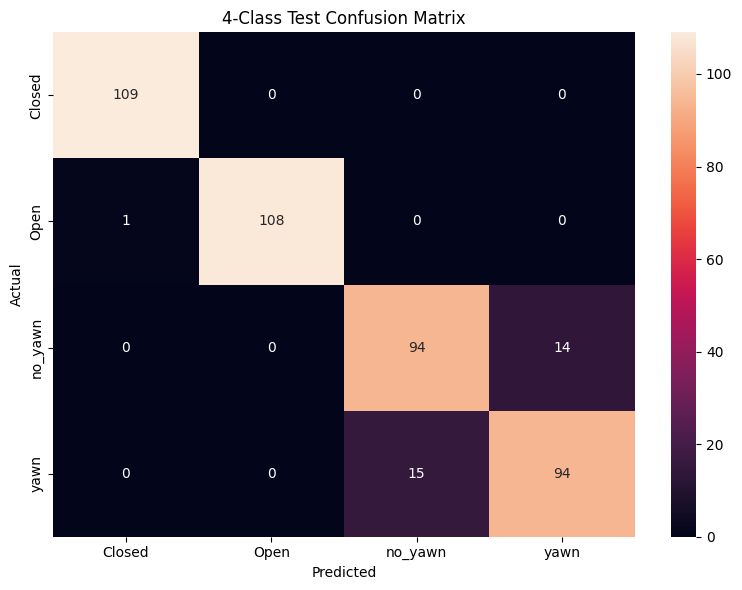


--- Specific Error Analysis ---
Closed predicted as Open: 0
Open predicted as Closed: 1
Yawn predicted as No_yawn: 15
No_yawn predicted as Yawn: 14


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(4))
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("4-Class Test Confusion Matrix")
plt.tight_layout()
plt.show()

# Calculate specific error types
closed_to_open = cm[CLASS_NAMES.index('Closed'), CLASS_NAMES.index('Open')]
open_to_closed = cm[CLASS_NAMES.index('Open'), CLASS_NAMES.index('Closed')]
yawn_to_noyawn = cm[CLASS_NAMES.index('yawn'), CLASS_NAMES.index('no_yawn')]
noyawn_to_yawn = cm[CLASS_NAMES.index('no_yawn'), CLASS_NAMES.index('yawn')]

print("\n--- Specific Error Analysis ---")
print(f"Closed predicted as Open: {closed_to_open}")
print(f"Open predicted as Closed: {open_to_closed}")
print(f"Yawn predicted as No_yawn: {yawn_to_noyawn}")
print(f"No_yawn predicted as Yawn: {noyawn_to_yawn}")

In [43]:
def combine_history(head_history, fine_history):
    history = {}

    for key in head_history.history:
        history[key] = (
            head_history.history[key]
            + fine_history.history.get(key, [])
        )

    return history


combined_history = combine_history(
    history_head,
    history_finetune
)

**Combining Training Histories:**
The model is trained in two stages: initial classifier training and MobileNetV2 fine-tuning. Each stage produces a separate Keras training history. This function combines the metrics from both histories into a single history dictionary, allowing the complete training and validation performance to be visualized as one continuous training process.

**Why it is needed:**
Since the model is trained in two separate stages, Keras stores the results of each stage in different history objects. Combining these histories makes it easier to analyze the model's overall learning progress, compare training and validation performance across both stages, and identify changes such as overfitting or improvement during fine-tuning.


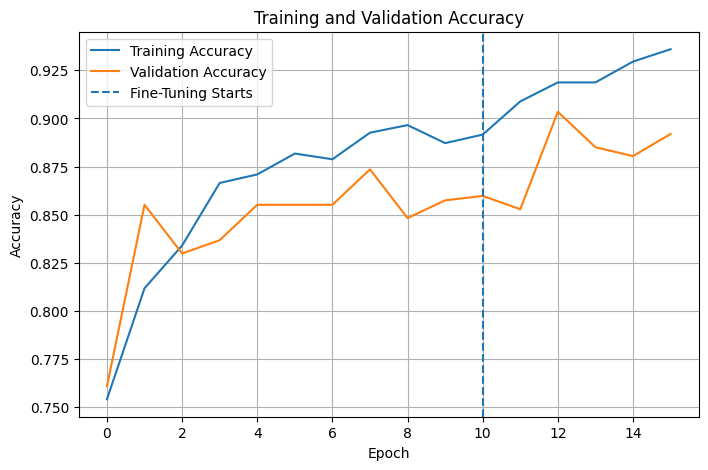

In [44]:
import matplotlib.pyplot as plt

head_epochs = len(history_head.history["accuracy"])
total_epochs = len(combined_history["accuracy"])

plt.figure(figsize=(8, 5))

plt.plot(
    combined_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    combined_history["val_accuracy"],
    label="Validation Accuracy"
)

# Mark where fine-tuning starts
plt.axvline(
    x=head_epochs - 1,
    linestyle="--",
    label="Fine-Tuning Starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The combined accuracy plot represents the training history of both the initial classifier-training phase and the subsequent fine-tuning phase. A vertical marker can be used to identify the transition between the two training stages.

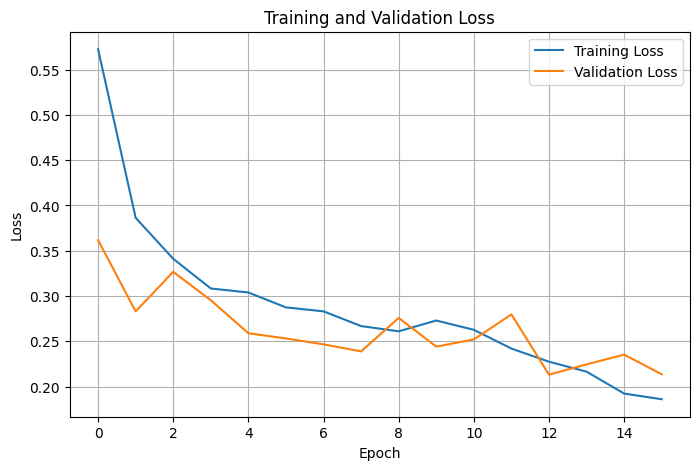

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    combined_history["loss"],
    label="Training Loss"
)

plt.plot(
    combined_history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
BINARY_MAPPING = {
    0: "DROWSY",  # Closed
    1: "ALERT",   # Open
    2: "ALERT",   # no_yawn
    3: "DROWSY"   # yawn
}

In [47]:
binary_true = np.array([
    BINARY_MAPPING[int(x)]
    for x in y_true
])

binary_pred = np.array([
    BINARY_MAPPING[int(x)]
    for x in y_pred
])

In [48]:
BINARY_CLASSES = [
    "ALERT",
    "DROWSY"
]

print(
    classification_report(
        binary_true,
        binary_pred,
        labels=BINARY_CLASSES,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       ALERT     0.9309    0.9309    0.9309       217
      DROWSY     0.9312    0.9312    0.9312       218

    accuracy                         0.9310       435
   macro avg     0.9310    0.9310    0.9310       435
weighted avg     0.9310    0.9310    0.9310       435



In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Convert 'DROWSY' to 1 and 'ALERT' to 0 for scikit-learn functions
# Assuming BINARY_CLASSES is ['ALERT', 'DROWSY'] where ALERT is 0 and DROWSY is 1
binary_true_numeric = np.array([1 if x == 'DROWSY' else 0 for x in binary_true])
binary_pred_numeric = np.array([1 if x == 'DROWSY' else 0 for x in binary_pred])


# Safety interpretation: DROWSY = positive class (1), ALERT = negative class (0)
# TP = DROWSY predicted as DROWSY (1,1)
# TN = ALERT predicted as ALERT (0,0)
# FP = ALERT predicted as DROWSY (0,1)
# FN = DROWSY predicted as ALERT (1,0)

# Calculate the binary confusion matrix
binary_cm = confusion_matrix(
    binary_true,
    binary_pred,
    labels=BINARY_CLASSES
)

# Extract TN, FP, FN, TP values from the `binary_cm` directly
# The order of labels for confusion_matrix was ['ALERT', 'DROWSY']
# cm[0,0] = TN (Actual ALERT, Predicted ALERT)
# cm[0,1] = FP (Actual ALERT, Predicted DROWSY)
# cm[1,0] = FN (Actual DROWSY, Predicted ALERT)
# cm[1,1] = TP (Actual DROWSY, Predicted DROWSY)

tn_binary = binary_cm[0, 0]
fp_binary = binary_cm[0, 1]
fn_binary = binary_cm[1, 0]
tp_binary = binary_cm[1, 1]

# Accuracy
overall_accuracy = accuracy_score(binary_true_numeric, binary_pred_numeric)

# Precision for DROWSY (positive class)
drowsy_precision = precision_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# Recall/Sensitivity for DROWSY (positive class)
drowsy_recall = recall_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# F1-score for DROWSY (positive class)
drowsy_f1 = f1_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# Specificity (Recall for ALERT, negative class)
alert_specificity = recall_score(binary_true_numeric, binary_pred_numeric, pos_label=0, zero_division=0)

# Total actual counts for FPR and FNR calculation
total_actual_alert = tn_binary + fp_binary
total_actual_drowsy = fn_binary + tp_binary

# False Positive Rate (FPR) = FP / (FP + TN) = FP / Total Actual ALERT
fpr = fp_binary / total_actual_alert if total_actual_alert > 0 else 0

# False Negative Rate (FNR) = FN / (FN + TP) = FN / Total Actual DROWSY
fnr = fn_binary / total_actual_drowsy if total_actual_drowsy > 0 else 0

print("--- Binary DROWSY / ALERT Test Set Metrics ---")
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"DROWSY Precision: {drowsy_precision:.4f}")
print(f"DROWSY Recall (Sensitivity): {drowsy_recall:.4f}")
print(f"DROWSY F1-score: {drowsy_f1:.4f}")
print(f"ALERT Specificity: {alert_specificity:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

--- Binary DROWSY / ALERT Test Set Metrics ---
Overall Accuracy: 0.9310
DROWSY Precision: 0.9312
DROWSY Recall (Sensitivity): 0.9312
DROWSY F1-score: 0.9312
ALERT Specificity: 0.9309
False Positive Rate (FPR): 0.0691
False Negative Rate (FNR): 0.0688


In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert 'DROWSY' to 1 and 'ALERT' to 0 for scikit-learn functions
# Assuming BINARY_CLASSES is ['ALERT', 'DROWSY'] where ALERT is 0 and DROWSY is 1
binary_true_numeric = np.array([1 if x == 'DROWSY' else 0 for x in binary_true])
binary_pred_numeric = np.array([1 if x == 'DROWSY' else 0 for x in binary_pred])


# Safety interpretation: DROWSY = positive class (1), ALERT = negative class (0)
# TP = DROWSY predicted as DROWSY (1,1)
# TN = ALERT predicted as ALERT (0,0)
# FP = ALERT predicted as DROWSY (0,1)
# FN = DROWSY predicted as ALERT (1,0)

# Extract TN, FP, FN, TP values from the `binary_cm` directly
# The order of labels for confusion_matrix was ['ALERT', 'DROWSY']
# cm[0,0] = TN (Actual ALERT, Predicted ALERT)
# cm[0,1] = FP (Actual ALERT, Predicted DROWSY)
# cm[1,0] = FN (Actual DROWSY, Predicted ALERT)
# cm[1,1] = TP (Actual DROWSY, Predicted DROWSY)

tn_binary = binary_cm[0, 0]
fp_binary = binary_cm[0, 1]
fn_binary = binary_cm[1, 0]
tp_binary = binary_cm[1, 1]

# Accuracy
overall_accuracy = accuracy_score(binary_true_numeric, binary_pred_numeric)

# Precision for DROWSY (positive class)
drowsy_precision = precision_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# Recall/Sensitivity for DROWSY (positive class)
drowsy_recall = recall_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# F1-score for DROWSY (positive class)
drowsy_f1 = f1_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# Specificity (Recall for ALERT, negative class)
alert_specificity = recall_score(binary_true_numeric, binary_pred_numeric, pos_label=0, zero_division=0)

# Total actual counts for FPR and FNR calculation
total_actual_alert = tn_binary + fp_binary
total_actual_drowsy = fn_binary + tp_binary

# False Positive Rate (FPR) = FP / (FP + TN) = FP / Total Actual ALERT
fpr = fp_binary / total_actual_alert if total_actual_alert > 0 else 0

# False Negative Rate (FNR) = FN / (FN + TP) = FN / Total Actual DROWSY
fnr = fn_binary / total_actual_drowsy if total_actual_drowsy > 0 else 0

print("--- Binary DROWSY / ALERT Test Set Metrics ---")
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"DROWSY Precision: {drowsy_precision:.4f}")
print(f"DROWSY Recall (Sensitivity): {drowsy_recall:.4f}")
print(f"DROWSY F1-score: {drowsy_f1:.4f}")
print(f"ALERT Specificity: {alert_specificity:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

--- Binary DROWSY / ALERT Test Set Metrics ---
Overall Accuracy: 0.9310
DROWSY Precision: 0.9312
DROWSY Recall (Sensitivity): 0.9312
DROWSY F1-score: 0.9312
ALERT Specificity: 0.9309
False Positive Rate (FPR): 0.0691
False Negative Rate (FNR): 0.0688


In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert 'DROWSY' to 1 and 'ALERT' to 0 for scikit-learn functions
# Assuming BINARY_CLASSES is ['ALERT', 'DROWSY'] where ALERT is 0 and DROWSY is 1
binary_true_numeric = np.array([1 if x == 'DROWSY' else 0 for x in binary_true])
binary_pred_numeric = np.array([1 if x == 'DROWSY' else 0 for x in binary_pred])


# Safety interpretation: DROWSY = positive class (1), ALERT = negative class (0)
# TP = DROWSY predicted as DROWSY (1,1)
# TN = ALERT predicted as ALERT (0,0)
# FP = ALERT predicted as DROWSY (0,1)
# FN = DROWSY predicted as ALERT (1,0)

# Accuracy
overall_accuracy = accuracy_score(binary_true_numeric, binary_pred_numeric)

# Precision for DROWSY (positive class)
drowsy_precision = precision_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# Recall/Sensitivity for DROWSY (positive class)
drowsy_recall = recall_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# F1-score for DROWSY (positive class)
drowsy_f1 = f1_score(binary_true_numeric, binary_pred_numeric, pos_label=1, zero_division=0)

# Specificity (Recall for ALERT, negative class)
alert_specificity = recall_score(binary_true_numeric, binary_pred_numeric, pos_label=0, zero_division=0)

# Confusion Matrix values should be available from the previous cell (IkvAbA20-SI8)
# tn_binary, fp_binary, fn_binary, tp_binary

total_actual_alert = tn_binary + fp_binary
total_actual_drowsy = fn_binary + tp_binary

# False Positive Rate (FPR) = FP / (FP + TN) = FP / Total Actual ALERT
fpr = fp_binary / total_actual_alert if total_actual_alert > 0 else 0

# False Negative Rate (FNR) = FN / (FN + TP) = FN / Total Actual DROWSY
fnr = fn_binary / total_actual_drowsy if total_actual_drowsy > 0 else 0

print("--- Binary DROWSY / ALERT Test Set Metrics ---")
print(f"Overall Accuracy: {overall_accuracy:.4f}")
print(f"DROWSY Precision: {drowsy_precision:.4f}")
print(f"DROWSY Recall (Sensitivity): {drowsy_recall:.4f}")
print(f"DROWSY F1-score: {drowsy_f1:.4f}")
print(f"ALERT Specificity: {alert_specificity:.4f}")
print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")

--- Binary DROWSY / ALERT Test Set Metrics ---
Overall Accuracy: 0.9310
DROWSY Precision: 0.9312
DROWSY Recall (Sensitivity): 0.9312
DROWSY F1-score: 0.9312
ALERT Specificity: 0.9309
False Positive Rate (FPR): 0.0691
False Negative Rate (FNR): 0.0688


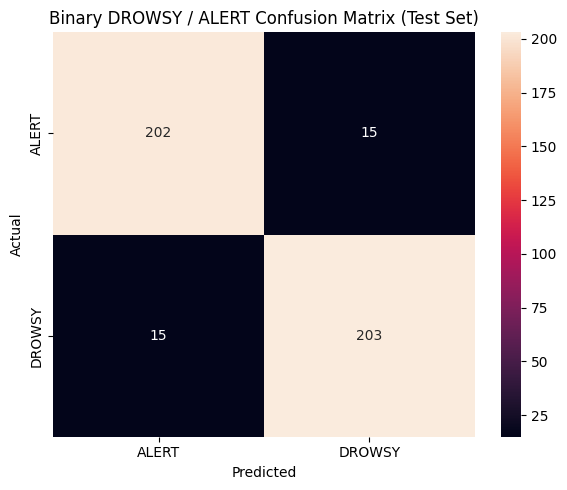


--- Binary Confusion Matrix Counts (Test Set) ---
True Negatives (Actual ALERT, Predicted ALERT): 202
False Positives (Actual ALERT, Predicted DROWSY): 15
False Negatives (Actual DROWSY, Predicted ALERT): 15
True Positives (Actual DROWSY, Predicted DROWSY): 203


In [52]:
binary_cm = confusion_matrix(
    binary_true,
    binary_pred,
    labels=BINARY_CLASSES
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    binary_cm,
    annot=True,
    fmt="d",
    xticklabels=BINARY_CLASSES,
    yticklabels=BINARY_CLASSES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary DROWSY / ALERT Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

# Extract values for clarity
tn_binary = binary_cm[0, 0] # Actual ALERT, Predicted ALERT
fp_binary = binary_cm[0, 1] # Actual ALERT, Predicted DROWSY
fn_binary = binary_cm[1, 0] # Actual DROWSY, Predicted ALERT
tp_binary = binary_cm[1, 1] # Actual DROWSY, Predicted DROWSY

print("\n--- Binary Confusion Matrix Counts (Test Set) ---")
print(f"True Negatives (Actual ALERT, Predicted ALERT): {tn_binary}")
print(f"False Positives (Actual ALERT, Predicted DROWSY): {fp_binary}")
print(f"False Negatives (Actual DROWSY, Predicted ALERT): {fn_binary}")
print(f"True Positives (Actual DROWSY, Predicted DROWSY): {tp_binary}")

In [53]:
def predict_image(path):
    path = str(path)

    image = Image.open(path).convert("RGB")

    image = image.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BILINEAR
    )

    image_array = np.asarray(
        image,
        dtype=np.float32
    )

    batch = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = model.predict(
        batch,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = float(
        probabilities[predicted_index]
    )

    if confidence < CONFIDENCE_THRESHOLD:
        final_status = "UNCERTAIN"
    elif predicted_class in {"Closed", "yawn"}:
        final_status = "DROWSY"
    else:
        final_status = "ALERT"

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "probabilities": {
            CLASS_NAMES[i]: float(probabilities[i])
            for i in range(4)
        },
        "final_status": final_status
    }

Single Image Prediction:
The predict_image() function takes an input image, preprocesses it to match the model's required input size, and uses the trained MobileNetV2-based model to predict the class probabilities. The class with the highest probability is selected as the predicted class, and its probability is used as the confidence score. Based on the confidence threshold and predicted class, the image is finally categorized as DROWSY, ALERT, or UNCERTAIN.

In [54]:
CONFIDENCE_THRESHOLD = 0.55

In [55]:
result = predict_image(
    df['path'][0] # Using an existing image path from the dataframe
)

print(
    "Prediction:",
    result["predicted_class"]
)

print(
    "Confidence:",
    f"{result['confidence'] * 100:.2f}%"
)

print(
    "Final Status:",
    result["final_status"]
)

print("\nAll probabilities:")

for name, probability in result["probabilities"].items():
    print(
        f"{name:10s}: {probability * 100:.2f}%"
    )

Prediction: Closed
Confidence: 100.00%
Final Status: DROWSY

All probabilities:
Closed    : 100.00%
Open      : 0.00%
no_yawn   : 0.00%
yawn      : 0.00%


In [56]:
# Assuming all variables like test_df, test_ds, y_true, y_pred,
# test_loss, test_accuracy, drowsy_precision, drowsy_recall, drowsy_f1,
# alert_specificity, fpr, fnr, fn_binary, fp_binary
# are defined and available from previous executed cells.

print("========== FINAL NOTEBOOK VERIFICATION ==========\n")

# Dataset sizes
train_samples = len(train_df)
val_samples = len(val_df)
test_samples = len(test_df)

print(f"Train samples: {train_samples}")
print(f"Validation samples: {val_samples}")
print(f"Test samples: {test_samples}\n")

# Check test_ds existence
print(f"Test dataset exists: {test_ds is not None}\n")

# Final Model (assuming fine_model was selected for final evaluation)
print(f"Final model: {final_model.name}\n")

# Test Performance
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# Binary Metrics (assuming these variables are defined)
print(f"DROWSY Precision: {drowsy_precision:.4f}")
print(f"DROWSY Recall: {drowsy_recall:.4f}")
print(f"DROWSY F1: {drowsy_f1:.4f}")
print(f"Specificity: {alert_specificity:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"False Negative Rate: {fnr:.4f}\n")

# Confusion Matrix counts (from IkvAbA20-SI8)
print(f"False Negatives (DROWSY -> ALERT): {fn_binary}")
print(f"False Positives (ALERT -> DROWSY): {fp_binary}\n")

# Assertions
assert test_ds is not None, "test_ds should not be None"
assert len(test_df) > 0, "test_df should not be empty"
assert len(y_true) == len(y_pred), "Length of y_true and y_pred must match"
assert len(y_true) == len(test_df), "Length of y_true must match test_df length"

print("================================================")
print("All assertions passed and key metrics verified.")

========== FINAL NOTEBOOK VERIFICATION ==========

Train samples: 2030
Validation samples: 435
Test samples: 435

Test dataset exists: True

Final model: driver_drowsiness_mobilenetv2

Test Loss: 0.1695
Test Accuracy: 0.9310

DROWSY Precision: 0.9312
DROWSY Recall: 0.9312
DROWSY F1: 0.9312
Specificity: 0.9309
False Positive Rate: 0.0691
False Negative Rate: 0.0688

False Negatives (DROWSY -> ALERT): 15
False Positives (ALERT -> DROWSY): 15

All assertions passed and key metrics verified.


In [57]:
import os
from google.colab import files

# Model selection based on validation loss, not test loss
# head_val_loss and fine_val_loss must be defined in previous cells
if fine_val_loss <= head_val_loss:
    final_model_path = BEST_FINE_TUNE_PATH
    print(f"Selected the fine-tuned model based on validation performance: {os.path.basename(final_model_path)}")
else:
    final_model_path = BEST_HEAD_PATH
    print(f"Selected the head model based on validation performance: {os.path.basename(final_model_path)}")

# Download the selected model
print(f"Downloading {os.path.basename(final_model_path)}...")
files.download(final_model_path)

# If you also want the class names, you can download them as well
# CLASS_NAMES_PATH was defined in cell R0cGRRhXgMpX
if 'CLASS_NAMES_PATH' in locals() and os.path.exists(CLASS_NAMES_PATH):
    print(f"Downloading {os.path.basename(CLASS_NAMES_PATH)}...")
    files.download(CLASS_NAMES_PATH)

Selected the fine-tuned model based on validation performance: best_finetuned.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
CLASS_NAMES_PATH = "/content/class_names.json"

with open(
    CLASS_NAMES_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        {
            "0": "Closed",
            "1": "Open",
            "2": "no_yawn",
            "3": "yawn"
        },
        f,
        indent=4
    )

print(open(CLASS_NAMES_PATH).read())

{
    "0": "Closed",
    "1": "Open",
    "2": "no_yawn",
    "3": "yawn"
}


In [59]:
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"Uploaded file: {filename}")

    # Make a prediction using the uploaded image
    result = predict_image(filename)

    print("\n--- Prediction Results ---")
    print(f"Predicted Class: {result['predicted_class']}")
    print(f"Confidence: {result['confidence'] * 100:.2f}%")
    print(f"Final Status: {result['final_status']}")

    print("\nAll Class Probabilities:")
    for name, probability in result["probabilities"].items():
        print(f"  {name:10s}: {probability * 100:.2f}%")


**Final Model Selection:**
The best models from the initial head-training stage and the MobileNetV2 fine-tuning stage are compared using their validation loss. The model with the lower validation loss is selected as the final model for testing and prediction. This ensures that the model with better validation performance is used for the final driver drowsiness classification task.

**Model Naming:**
The architecture is named `driver_drowsiness_mobilenetv2` when the Keras model is created. The files `best_head.keras` and `best_finetuned.keras` are saved checkpoints representing the best-performing versions from their respective training stages.
